# create_agent 範例

最小可執行範例：一個 model + 一個 tool，示範 `langchain.agents.create_agent` 怎麼用。
照專案習慣先只接一個工具，確認流程沒問題後再依序加入更多（可參考 `agent.py` 裡完整版本）。

In [15]:
import os

import dotenv
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_openai import ChatOpenAI

# 讀取專案根目錄的 .env，取得 MODEL_NAME / MODEL_URL / MODEL_KEY。
dotenv.load_dotenv()

model = ChatOpenAI(
    model=os.environ["MODEL_NAME"],
    base_url=os.environ["MODEL_URL"],
    api_key=os.environ["MODEL_KEY"],
    temperature=0,
)

In [16]:
# 先定義一個最簡單的工具，用來驗證 create_agent 的基本流程能不能跑通。
@tool
def get_current_time() -> str:
    """回傳目前的日期與時間，格式為 YYYY-MM-DD HH:MM:SS。"""
    from datetime import datetime

    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

In [17]:
# 示範 response_format="content_and_artifact"：
# 工具可以回傳一個 (content, artifact) tuple。
# - content：會被放進 ToolMessage.content，這段才會送進模型的 context，保持精簡。
# - artifact：掛在 ToolMessage.artifact，模型看不到、不會佔 context，
#   但應用程式（例如 Gradio 畫面）拿得到，可以用來渲染圖片。
import base64
import io

from PIL import Image


@tool(response_format="content_and_artifact")
def render_test_image(color: str = "red") -> tuple[str, str]:
    """畫一張 64x64 的純色測試圖片，顏色可指定（例如 red、blue、green）。"""

    image = Image.new("RGB", (64, 64), color=color)
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    image_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

    content = f"已產生一張 {color} 色的測試圖片"
    artifact = f"data:image/png;base64,{image_base64}"
    return content, artifact

In [18]:
# create_agent 把 model 跟 tools 組成一個可以直接呼叫的 agent（背後是一張 LangGraph 圖）。
workflow = create_agent(
    model,
    tools=[get_current_time, render_test_image],
)

In [19]:
# 改用 stream，不用等整輪跑完，模型一產生內容就一邊印出來。
# stream_mode="messages" 每次會吐出 (chunk, metadata)：
# chunk 是這次新產生的訊息片段，metadata 是這個片段來自哪個節點等資訊。
#
# 完整流程分三種 chunk，順序就是「先 tool_call，工具執行完才有 tool message」：
# 1. ai + tool_call_chunks/tool_calls：模型決定呼叫哪個工具、帶什麼參數（執行「前」）
# 2. tool：工具實際執行完的回傳結果（執行「後」）
# 3. ai + content：模型看到工具結果後，組出來的最終回覆文字
#
# chunk 型別可能是 AIMessageChunk（正常串流片段，有 tool_call_chunks，
# args 是還沒接完的字串片段），也可能是完整的 AIMessage（langchain create_agent
# 在 astream 底下的已知 bug，這時候要改看 tool_calls，args 已經是解析好的 dict）。
# 兩個屬性都用 getattr 防呆讀取，讀不到就當作 None，不會噴 AttributeError。
for chunk, metadata in workflow.stream(
    {"messages": [{"role": "user", "content": "現在幾點？"}]},
    stream_mode="messages",
):
    if chunk.type == "ai":
        tool_call_chunks = getattr(chunk, "tool_call_chunks", None)
        tool_calls = getattr(chunk, "tool_calls", None)
        if tool_call_chunks:
            for call in tool_call_chunks:
                print(f"\n[tool_call_chunk] {call['name']} args={call['args']}\n")
        elif tool_calls:
            for call in tool_calls:
                print(f"\n[tool_call] {call['name']} args={call['args']}\n")
        elif chunk.content:
            print(chunk.content, end="", flush=True)
    elif chunk.type == "tool":
        print(f"\n[tool:{chunk.name}] {chunk.content}\n")


[tool:get_current_time] 2026-08-04 20:30:59



In [20]:
# workflow 除了同步的 invoke/stream，也有對應的 async 版本：ainvoke/astream。
# Jupyter 的 cell 本身就支援 top-level await，所以可以直接在 cell 裡寫 async for，
# 不用自己包一層 asyncio.run(...)。
#
# 跟上一格同樣的防呆邏輯：astream 底下 chunk 更容易拿到完整的 AIMessage
# （而不是 AIMessageChunk），所以 tool_call_chunks 讀不到時要 fallback 去讀 tool_calls。
async for chunk, metadata in workflow.astream(
    {"messages": [{"role": "user", "content": "現在幾點？"}]},
    stream_mode="messages",
):
    if chunk.type == "ai":
        tool_call_chunks = getattr(chunk, "tool_call_chunks", None)
        tool_calls = getattr(chunk, "tool_calls", None)
        if tool_call_chunks:
            for call in tool_call_chunks:
                print(f"\n[tool_call_chunk] {call['name']} args={call['args']}\n")
        elif tool_calls:
            for call in tool_calls:
                print(f"\n[tool_call] {call['name']} args={call['args']}\n")
        elif chunk.content:
            print(chunk.content, end="", flush=True)
    elif chunk.type == "tool":
        print(f"\n[tool:{chunk.name}] {chunk.content}\n")


[tool_call] get_current_time args={}


[tool:get_current_time] 2026-08-04 20:31:03

現在是 2026年8月4日 20:31:03。

In [21]:
# stream_mode="updates"：跟 "messages" 不一樣，這裡吐的不是 token 片段，
# 而是「每個節點（node）跑完之後新增了哪些完整訊息」。
# 每次拿到的 update 是 {節點名稱: {"messages": [新增的訊息, ...]}}，
# 因為都是跑完才給的完整 Message，不會遇到 tool_call_chunks / AIMessageChunk
# 那些半成品 chunk 的問題，適合拿來做「一步一步顯示進度」的效果。
for update in workflow.stream(
    {"messages": [{"role": "user", "content": "現在幾點？"}]},
    stream_mode="updates",
):
    for node_name, node_output in update.items():
        for message in node_output["messages"]:
            if message.type == "ai" and message.tool_calls:
                for call in message.tool_calls:
                    print(f"[tool_call] {call['name']} args={call['args']}")
            elif message.type == "tool":
                print(f"[tool:{message.name}] {message.content}")
            elif message.type == "ai" and message.content:
                print(f"[assistant] {message.content}")

[tool_call] get_current_time args={}
[tool:get_current_time] 2026-08-04 20:31:06
[assistant] 現在是 2026年8月4日 20:31:06。


In [22]:
# stream_events(version="v3") 是 langchain v1.3+ 官方對「新專案」建議的串流方式，
# 用 .interleave(...) 把「文字 token」跟「工具呼叫」兩條事件流分開消費，
# 不用再自己判斷 chunk 到底是 AIMessageChunk 還是 AIMessage。
#
# 注意：目前這是 experimental（實驗性）功能，跑起來會看到
# LangChainBetaWarning，之後版本介面可能還會改，正式環境要接之前先評估風險。
stream = workflow.stream_events(
    {"messages": [{"role": "user", "content": "現在幾點？"}]},
    version="v3",
)
for kind, item in stream.interleave("messages", "tool_calls"):
    if kind == "messages":
        for token in item.text:
            print(token, end="", flush=True)
    elif kind == "tool_calls":
        print(f"\n[tool_call] {item.tool_name}({item.input})")
        print(f"[tool_result] {item.output}")

/home/houzeyu2683/.conda/envs/DAA/lib/python3.10/site-packages/langgraph/pregel/main.py:3723: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
/home/houzeyu2683/.conda/envs/DAA/lib/python3.10/site-packages/langgraph/pregel/main.py:3573: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)



[tool_call] get_current_time({})
[tool_result] None
現在是 2026年8月4日 20:31:08。

[tool_call] render_test_image args={'color': 'blue'}
[tool_content 進 context] '已產生一張 blue 色的測試圖片'
[tool_artifact 長度，不進 context] 226 字元



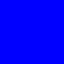

[assistant] 這是一張藍色的測試圖片。


In [23]:
# 驗證 content_and_artifact：印出 content（進模型 context 的那段，應該很短）
# 跟 artifact 的長度（base64 圖片，不會進模型 context），並把圖片實際渲染出來看看。
from IPython.display import HTML, display

for update in workflow.stream(
    {"messages": [{"role": "user", "content": "幫我畫一張藍色的測試圖片"}]},
    stream_mode="updates",
):
    for node_output in update.values():
        for message in node_output["messages"]:
            if message.type == "ai" and message.tool_calls:
                for call in message.tool_calls:
                    print(f"[tool_call] {call['name']} args={call['args']}")
            elif message.type == "tool":
                artifact_length = len(message.artifact) if message.artifact else 0
                print(f"[tool_content 進 context] {message.content!r}")
                print(f"[tool_artifact 長度，不進 context] {artifact_length} 字元")
                if message.artifact:
                    display(HTML(f'<img src="{message.artifact}" />'))
            elif message.type == "ai" and message.content:
                print(f"[assistant] {message.content}")

In [29]:
from string import Template
template = Template("""你是一個檔案助理，目前工作目錄如下：

資料夾：$folder
檔案數量：$file_count
使用者名稱：$username
""")

context = {
    "folder": "/home/houzeyu2683/Documents/Projects/DAA",
    "username": "houzeyu2683",
    "file_count": None,
}

system_prompt = template.substitute(context)

In [30]:
system_prompt

'你是一個檔案助理，目前工作目錄如下：\n\n資料夾：/home/houzeyu2683/Documents/Projects/DAA\n檔案數量：None\n使用者名稱：houzeyu2683\n'